# 07. Índice de Calidad de Datos (DQS) Final

Este notebook representa la fase final de medición en el marco TDQM. Aquí cuantificamos la mejora técnica del proyecto comparando el estado inicial de los datos con el dataset consolidado final.

**Fórmula del DQS:**
$$DQS = (Completitud \times 0.30) + (Consistencia \times 0.25) + (Unicidad \times 0.25) + (Validez \times 0.20)$$

**Dimensiones:**
1. **Completitud**: Ausencia de nulos.
2. **Consistencia**: Estandarización de formatos y dominios.
3. **Unicidad**: Ausencia de duplicados exactos y difusos.
4. **Validez**: Adherencia a rangos de negocio (Lead Time, ADR).

In [27]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Configuración de rutas
PROCESSED_PATH = '../data/processed/'
RESULTS_PATH = '../data/results/'

# Carga de datos finales y métricas iniciales
df_final = pd.read_csv(os.path.join(PROCESSED_PATH, 'consolidated_bookings.csv'))
with open(os.path.join(RESULTS_PATH, 'initial_metrics.json'), 'r') as f:
    m_initial = json.load(f)

print(f"Dataset consolidado cargado: {df_final.shape}")

Dataset consolidado cargado: (123856, 34)


## 1. Cálculo de Métricas Finales
Evaluamos las dimensiones de calidad sobre el producto final.

In [28]:
total_rows = len(df_final)
total_cells = df_final.size

# A. Completitud
m_completitud = (df_final.notnull().sum().sum() / total_cells) * 100

# B. Consistencia
regex_iso = r'^\d{4}-\d{2}-\d{2}$'
valid_dates = df_final['arrival_date'].astype(str).str.match(regex_iso).sum()
m_consistencia = (valid_dates / total_rows) * 100

# C. Unicidad
m_unicidad = (1 - (df_final.duplicated(subset=['name', 'email', 'phone_number']).sum() / total_rows)) * 100

# D. Validez
valid_lt = df_final['lead_time'].between(0, 365).sum()
valid_adr = df_final['average_daily_rate'].between(0, 1000).sum()
m_validez = ((valid_lt + valid_adr) / (2 * total_rows)) * 100

m_final = {
    "completitud": round(m_completitud, 2),
    "consistencia": round(m_consistencia, 2),
    "unicidad": round(m_unicidad, 2),
    "validez": round(m_validez, 2)
}

print("Métricas de Calidad Finales:")
print(json.dumps(m_final, indent=4))

Métricas de Calidad Finales:
{
    "completitud": 96.65,
    "consistencia": 98.2,
    "unicidad": 100.0,
    "validez": 100.0
}


## 2. Cálculo del DQS (Data Quality Score)
Aplicamos la ponderación de negocio.

In [29]:
def calculate_dqs(m):
    return (m['completitud'] * 0.30) + (m['consistencia'] * 0.25) + \
           (m['unicidad'] * 0.25) + (m['validez'] * 0.20)

dqs_inicial = calculate_dqs(m_initial)
dqs_final = calculate_dqs(m_final)

print(f"DQS Inicial: {dqs_inicial:.2f}")
print(f"DQS Final: {dqs_final:.2f}")
print(f"Mejora Absoluta: {dqs_final - dqs_inicial:.2f} puntos")

DQS Inicial: 72.94
DQS Final: 98.55
Mejora Absoluta: 25.60 puntos


## 3. Visualización de la Mejora
Generamos una comparativa visual para el reporte ejecutivo usando Matplotlib.

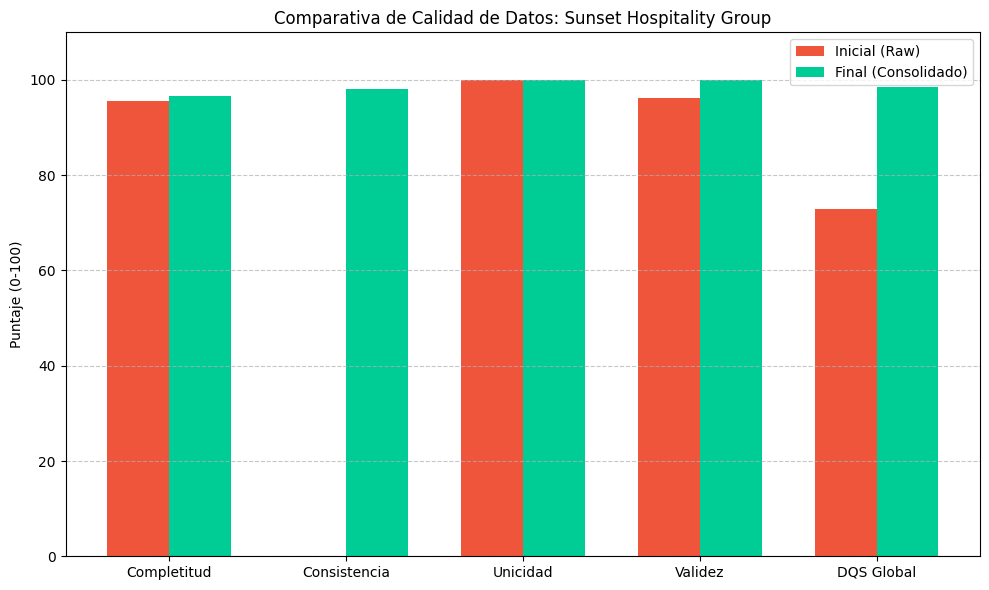

In [30]:
dimensiones = ['Completitud', 'Consistencia', 'Unicidad', 'Validez', 'DQS Global']
valores_ini = [m_initial['completitud'], m_initial['consistencia'], m_initial['unicidad'], m_initial['validez'], dqs_inicial]
valores_fin = [m_final['completitud'], m_final['consistencia'], m_final['unicidad'], m_final['validez'], dqs_final]

x = np.arange(len(dimensiones))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, valores_ini, width, label='Inicial (Raw)', color='#EF553B')
rects2 = ax.bar(x + width/2, valores_fin, width, label='Final (Consolidado)', color='#00CC96')

ax.set_ylabel('Puntaje (0-100)')
ax.set_title('Comparativa de Calidad de Datos: Sunset Hospitality Group')
ax.set_xticks(x)
ax.set_xticklabels(dimensiones)
ax.legend()
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 4. Exportación de Resultados
Guardamos la tabla comparativa final.

In [31]:
df_comparison = pd.DataFrame({
    'Dimension': dimensiones,
    'Initial': valores_ini,
    'Final': valores_fin
})

df_comparison.to_csv(os.path.join(RESULTS_PATH, 'dqs_comparison.csv'), index=False)

print(f"[OK] Tabla comparativa guardada en {RESULTS_PATH}")

[OK] Tabla comparativa guardada en ../data/results/
